In [1]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data
from torch.autograd import Variable
from tqdm import tqdm

from sklearn.model_selection import train_test_split

In [2]:
import matplotlib.pyplot as plt
import math

%matplotlib inline

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("CPU")

CPU


In [4]:
data_train = pd.read_csv("digit-recognizer/train.csv", dtype = np.float32)
print("Number of training:",data_train.shape[0])

Number of training: 42000


In [5]:
data_train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
X = data_train.drop("label", axis=1).values/255
y = data_train["label"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)
X_train= X_train.reshape(-1, 1, 28, 28)
X_test= X_test.reshape(-1, 1, 28, 28)

In [7]:
def plot_sample_images(X, y, ncols=5, num=25):
    num = int(min(num, len(y)))
    nrows = math.ceil(num / ncols)
    fig, axes = plt.subplots(ncols=ncols, nrows=nrows, figsize=(ncols, nrows))
    fig.subplots_adjust(hspace=0.8)
    for i, ax in enumerate(axes.flatten()):
        if i < num:
            ax.imshow(X.max()-X[i].reshape(28, 28), cmap="gray")
            ax.set_title(str(y[i]))
        ax.axis('off')
    plt.show()

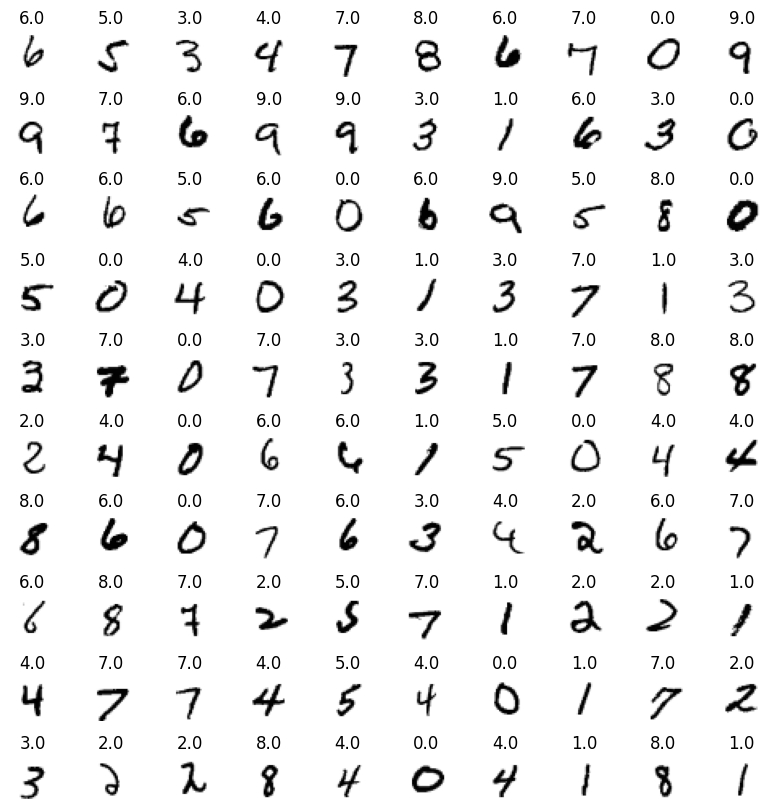

In [8]:
plot_sample_images(X_train, y_train, ncols=10, num=100)

In [9]:
BATCH_SIZE = 100

torch_X_train = torch.from_numpy(X_train)
torch_y_train = torch.from_numpy(y_train).type(torch.LongTensor)

torch_X_test = torch.from_numpy(X_test)
torch_y_test = torch.from_numpy(y_test).type(torch.LongTensor)

In [10]:
# Pytorch train and test sets
train = torch.utils.data.TensorDataset(torch_X_train, torch_y_train)
test = torch.utils.data.TensorDataset(torch_X_test, torch_y_test)

# data loader
train_loader = torch.utils.data.DataLoader(train, batch_size = BATCH_SIZE, shuffle = False)
test_loader = torch.utils.data.DataLoader(test, batch_size = BATCH_SIZE, shuffle = False)

In [ ]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=5, stride=1, padding=0)
        self.cnn2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=5, stride=1, padding=0)
        # self.fc0 = nn.Dropout(0.25)
        self.fc1 = nn.LazyLinear(10)

    def forward(self, x):
        out = torch.relu(self.cnn1(x))
        out = torch.relu(self.cnn2(out))
        out = out.view(out.size(0), -1)
        # out = self.fc0(out)
        out = self.fc1(out)
        return out

# batch_size, epoch and iteration
batch_size = BATCH_SIZE

model = CNNModel()
model.to(device)
error = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size = 2, gamma = 0.1)
num_epochs = 10



In [12]:
# CNN model training
count = 0
loss_list = []
iteration_list = []
accuracy_list = []
for epoch in tqdm(range(num_epochs)):
    for i, (images, labels) in enumerate(train_loader):
        
        train = images.to(device)
        labels = labels.to(device)

        # Clear gradients
        optimizer.zero_grad()
        outputs = model(train)

        # Calculate softmax and ross entropy loss
        loss = error(outputs, labels)

        # Calculating gradients
        loss.backward()

        # Update parameters
        optimizer.step()

        count += 1

        if count % 50 == 0:
            # Calculate Accuracy
            correct = 0
            total = 0
            # Iterate through test dataset
            for images, labels in test_loader:

                test = images.to(device)

                # Forward propagation
                outputs = model(test)

                # Get predictions from the maximum value
                predicted = torch.max(outputs, 1)[1]

                # Total number of labels
                total += len(labels)

                correct += (predicted  == labels).sum().item()

            accuracy = 100 * correct / float(total)

            # store loss and iteration
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)
        if count % 250 == 0:
            # Print Loss
            print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.item(), accuracy))
    scheduler.step()

  0%|          | 0/10 [00:00<?, ?it/s]

Iteration: 250  Loss: 0.09830989688634872  Accuracy: 95.14285714285714 %


 10%|█         | 1/10 [00:20<03:06, 20.72s/it]

Iteration: 500  Loss: 0.1181005984544754  Accuracy: 97.26190476190476 %


 20%|██        | 2/10 [00:41<02:44, 20.59s/it]

...

 80%|████████  | 8/10 [02:41<00:39, 19.88s/it]

Iteration: 2750  Loss: 0.054061174392700195  Accuracy: 97.94047619047619 %
Iteration: 3000  Loss: 0.008465045131742954  Accuracy: 98.07142857142857 %


 90%|█████████ | 9/10 [03:02<00:20, 20.15s/it]

Iteration: 3250  Loss: 0.026516370475292206  Accuracy: 98.02380952380952 %


100%|██████████| 10/10 [03:21<00:00, 20.19s/it]


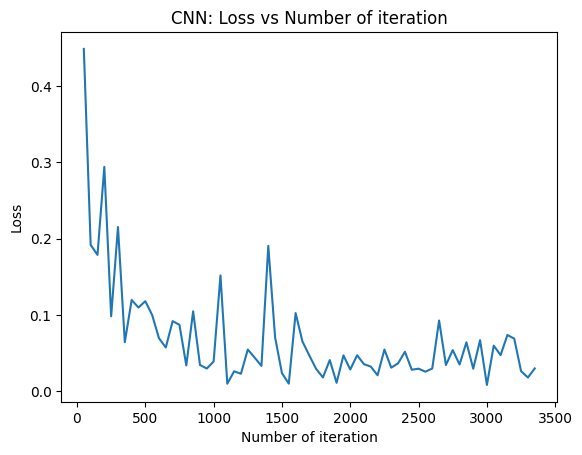

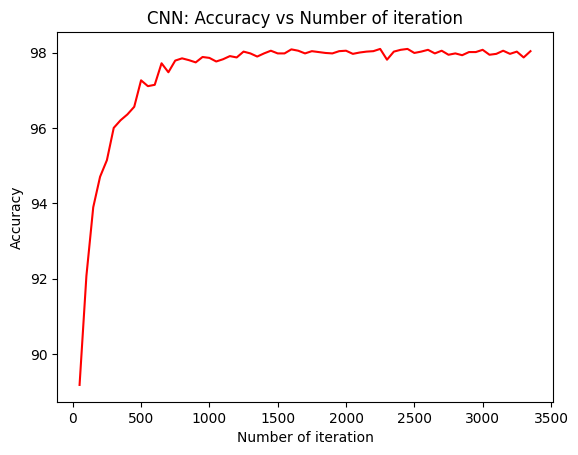

In [13]:
# visualization loss
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("CNN: Loss vs Number of iteration")
plt.show()

# visualization accuracy
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("CNN: Accuracy vs Number of iteration")
plt.show()